06 JUNE 2026
---

New dataset: https://data.mendeley.com/datasets/d9scg7j8fp/1

(CAIR-CVD-2025: An Extensive Cardiovascular Disease Risk Assessment Dataset from Bangladesh)



1. Business Understanding: Shulei + Kausaliya
2. Data Understanding & EDA:  Shulei + Kausaliya
3. Data Preparation + Missing data handling: Sindhu  
4. Modeling:
  A. Random Forest Classifier: Keng
  B. Logictic Regression: Rakib
5. Evaluation: current metrics on 5.1 Evaluation Metrics (sync with 4)
6. Deployment: Streamlit app (Hajar)


Workflow:

EDA -> Data perparation -> Modeling -> Deployment



## WQD7003 DATA ANALYTICS — Group (09)
# Heart Disease Risk Prediction: A Classification-Based Data Mining Study

**Dataset:** [CAIR-CVD-2025: An Extensive Cardiovascular Disease Risk Assessment Dataset from Bangladesh](https://data.mendeley.com/datasets/d9scg7j8fp/1)

| Member | Student ID | Role |
|--------|-----------|------|
| Xiao Shulei | 25084582 | Business Understanding + Data Understanding + EDA |
| Kausaliya A/P Nanthakumar | 17206793 | Business Understanding + Data Understanding + EDA |
| Ung Keng Jie | 25084156 | Modelling + Evaluation |
| Shindujaah Jaya Kumar | 25087626 | Data Preparation |
| Rakib Hasann | 23099815 | Modelling + Evaluation |
| Hajar Amani Binti Hamim | 25087789 | Deployment |

---
# CRISP-DM Framework
## 1. Business Understanding
*(Authors: Xiao Shulei, Kausaliya)*

### 1.1 Background

Cardiovascular disease (CVD) is the leading cause of death globally and a rapidly growing burden in South Asia, where it often presents earlier and with higher severity than in Western populations. In resource-constrained settings such as Bangladesh, hospitals frequently lack the capacity for systematic, early risk screening. This dataset (CAIR-CVD-2025) contains 1,529 patient records collected at Jamalpur Medical College Hospital between January 2024 and January 2025, covering demographic, anthropometric, clinical, biochemical, and lifestyle parameters. It offers an opportunity to build a data-driven tool that supports early identification of patients at elevated cardiovascular risk.



### 1.2 Business Objectives

*   Enable early, low-cost identification of patients at elevated cardiovascular risk, so limited clinical resources can be prioritised toward those most in need.
*   Provide clinicians with an interpretable screening aid that complements, not replaces, professional judgement.
*   Identify the dominant modifiable risk factors (e.g., smoking, blood pressure, cholesterol) to support targeted preventive health interventions.
*   Reduce the rate of undetected high-risk cases reaching late-stage disease, easing the long-term burden on the healthcare system.




### 1.3 Business Success Criteria

*   The model reliably flags high-risk patients with few missed cases, making it suitable as a first-pass triage / screening support tool.
*   The identified risk drivers are clinically plausible and align with established cardiovascular medicine.
*   The tool is simple enough to be applied with routinely collected hospital data, requiring no specialised or costly tests.
*   Clinicians find the outputs actionable enough to inform follow-up or referral decisions.

### 1.4 Data Mining / Analytics Goals

*   Frame the problem as a supervised multi-class classification task predicting CVD Risk Level (e.g., Low / Moderate / High).
*   Use demographic, anthropometric, clinical, biochemical, and lifestyle features as predictors, after removing leakage-prone and redundant fields.
*   Rank feature importance to determine which factors most strongly drive risk.
*   Compare multiple algorithms (e.g., Logistic Regression, Random Forest) and select the best performer through cross-validation.

### 1.5 Analytics Success Criteria

*   Prioritise recall on the high-risk class, since a missed high-risk patient is far costlier than a false alarm.
*   Report macro-averaged F1 alongside accuracy, because the classes are likely imbalanced and accuracy alone would be misleading.
*   Achieve performance that meaningfully exceeds a majority-class baseline.
*   Maintain stable cross-validated scores (low variance across folds) to ensure the model generalises rather than overfits.


### 1.6 Situation Assessment (Constraints & Risks)

*   Sample scope: Data come from a single hospital in one region of Bangladesh; findings may not generalise to other populations (selection / geographic bias).
*   Potential data leakage: The dataset contains a numeric CVD Risk Score and a categorical CVD Risk Level. The latter is likely derived from the former, so CVD Risk Score (and possibly other engineered fields such as Blood Pressure Category, Waist-to-Height Ratio, and Estimated LDL) must be examined and likely excluded from the predictors to avoid target leakage.
*   Redundant features: Height is recorded in both metres and centimetres, and BMI is derived from weight and height — these redundancies will be handled in pre-processing.
*   Class imbalance: Risk levels are unlikely to be evenly distributed, which must inform both metric selection and any resampling strategy.



---
## 2. Exploratory Data Analysis (EDA)
*(Authors: Xiao Shulei, Kausaliya)*

In this section we explore the dataset to understand its structure, data quality,
the distribution of the target variable, and the relationships between features and
CVD risk. The goal is to surface insights that will guide pre-processing and
modelling. Note: EDA here *identifies* data-quality issues (missing values,
outliers); the actual handling is performed in the Data Pre-processing section.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "CVD Dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (1529, 22)


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,CVD Risk Level,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,N,Y,Low,N,INTERMEDIARY,171.0,0.504,125.0,79.0,Elevated,140.0,17.93
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,Y,Y,High,Y,HIGH,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,N,N,High,Y,INTERMEDIARY,183.0,0.583,104.0,77.0,Normal,0.0,12.64
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,N,N,High,Y,INTERMEDIARY,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,Y,Y,High,N,INTERMEDIARY,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

In [3]:
TARGET = "CVD Risk Level"

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()


if TARGET in numeric_cols: numeric_cols.remove(TARGET)
if TARGET in categorical_cols: categorical_cols.remove(TARGET)

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

df.describe(include="all").T

Numeric features: ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)', 'CVD Risk Score']
Categorical features: ['Sex', 'Blood Pressure (mmHg)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sex,1529,2,F,773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1451.0,NaN,NaN,NaN,47.0255,12.421063,25.0,37.0,46.0,55.0,79.0
Weight (kg),1448.0,NaN,NaN,NaN,85.917427,21.01258,50.1,67.05,86.6145,105.0,120.0
Height (m),1462.0,NaN,NaN,NaN,1.754111,0.11309,1.502,1.66,1.755,1.8455,2.0
BMI,1465.0,NaN,NaN,NaN,28.465997,7.038685,15.0,22.629,28.159,34.0,46.2
Abdominal Circumference (cm),1462.0,NaN,NaN,NaN,91.773214,12.823573,70.0,80.5,91.6,102.269,119.996
Blood Pressure (mmHg),1529,1254,127/84,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Cholesterol (mg/dL),1456.0,NaN,NaN,NaN,198.539148,57.794099,100.0,150.0,197.0,249.0,300.0
HDL (mg/dL),1449.0,NaN,NaN,NaN,56.197378,16.066754,30.0,42.0,56.0,70.0,89.0
Fasting Blood Sugar (mg/dL),1462.0,NaN,NaN,NaN,117.485636,30.289174,70.0,92.0,115.0,138.0,198.0


The minimum value of Estimated LDL is -18, and zero values are also present. Since LDL cannot be negative, these are obvious data entry or calculation errors.


## 2.1 Missing Values¶

We first quantify missingness per column to assess data completeness.

                              missing_count  missing_%
Diastolic BP                             82       5.36
Weight (kg)                              81       5.30
HDL (mg/dL)                              80       5.23
Waist-to-Height Ratio                    79       5.17
Age                                      78       5.10
Height (cm)                              74       4.84
Total Cholesterol (mg/dL)                73       4.77
Systolic BP                              71       4.64
CVD Risk Score                           70       4.58
Estimated LDL (mg/dL)                    69       4.51
Height (m)                               67       4.38
Abdominal Circumference (cm)             67       4.38
Fasting Blood Sugar (mg/dL)              67       4.38
BMI                                      64       4.19


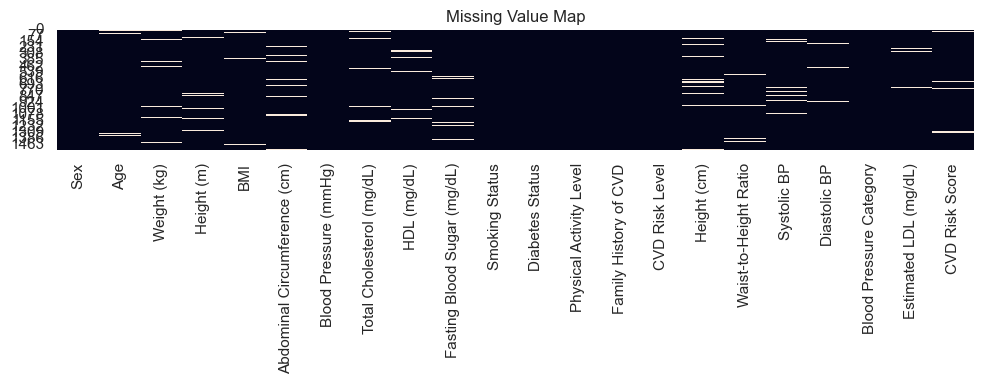

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = (pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
                 .query("missing_count > 0")
                 .sort_values("missing_count", ascending=False))
print(missing_table if not missing_table.empty else "No missing values detected.")

plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Value Map")
plt.tight_layout(); plt.show()

The 14 numeric columns each have a missing rate of around 4%–5% (max: 5.36% for Diastolic BP, min: 4.19% for BMI). The 7 categorical columns and target column are fully complete.



# 2.2 Target Variable Distribution
Understanding the class balance of CVD Risk Level is critical: it determines which evaluation metrics are appropriate and whether resampling is needed in modelling.

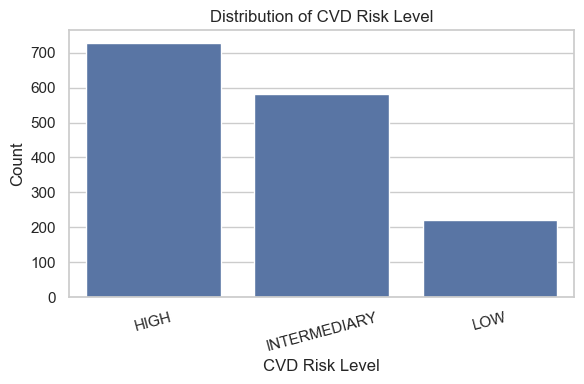

CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64

Proportion:
 CVD Risk Level
HIGH            47.61
INTERMEDIARY    38.00
LOW             14.39
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
order = df[TARGET].value_counts().index
sns.countplot(data=df, x=TARGET, order=order)
plt.title("Distribution of CVD Risk Level")
plt.ylabel("Count"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

print(df[TARGET].value_counts())
print("\nProportion:\n", (df[TARGET].value_counts(normalize=True) * 100).round(2))

Moderate class imbalance exists; LOW is the minority class. The majority class baseline is 47.6%. The model must outperform this benchmark noticeably to be practical.

# 2.3 Data Leakage Check: CVD Risk Score vs CVD Risk Level
The dataset contains both a numeric CVD Risk Score and the categorical target CVD Risk Level. If the level is simply a binned version of the score, including the score as a predictor would constitute target leakage. We examine their relationship to decide which features must be excluded before modelling.

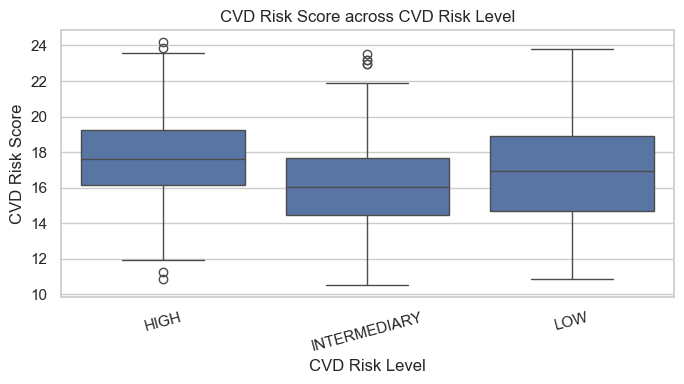

                  min     max       mean
CVD Risk Level                          
HIGH            10.89  24.170  17.611323
INTERMEDIARY    10.53  23.510  16.133444
LOW             10.86  23.797  17.006419


In [6]:
SCORE_COL = "CVD Risk Score"

if SCORE_COL in df.columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=TARGET, y=SCORE_COL, order=order)
    plt.title("CVD Risk Score across CVD Risk Level")
    plt.xticks(rotation=15)
    plt.tight_layout(); plt.show()


    print(df.groupby(TARGET)[SCORE_COL].agg(["min", "max", "mean"]))
else:
    print(f"'{SCORE_COL}' not found — check exact column name.")

The box plots of the three groups' scores fully overlap, and their mean values show no distinct order. Conclusion: There is no data leakage, and the CVD Risk Score is a weak feature.

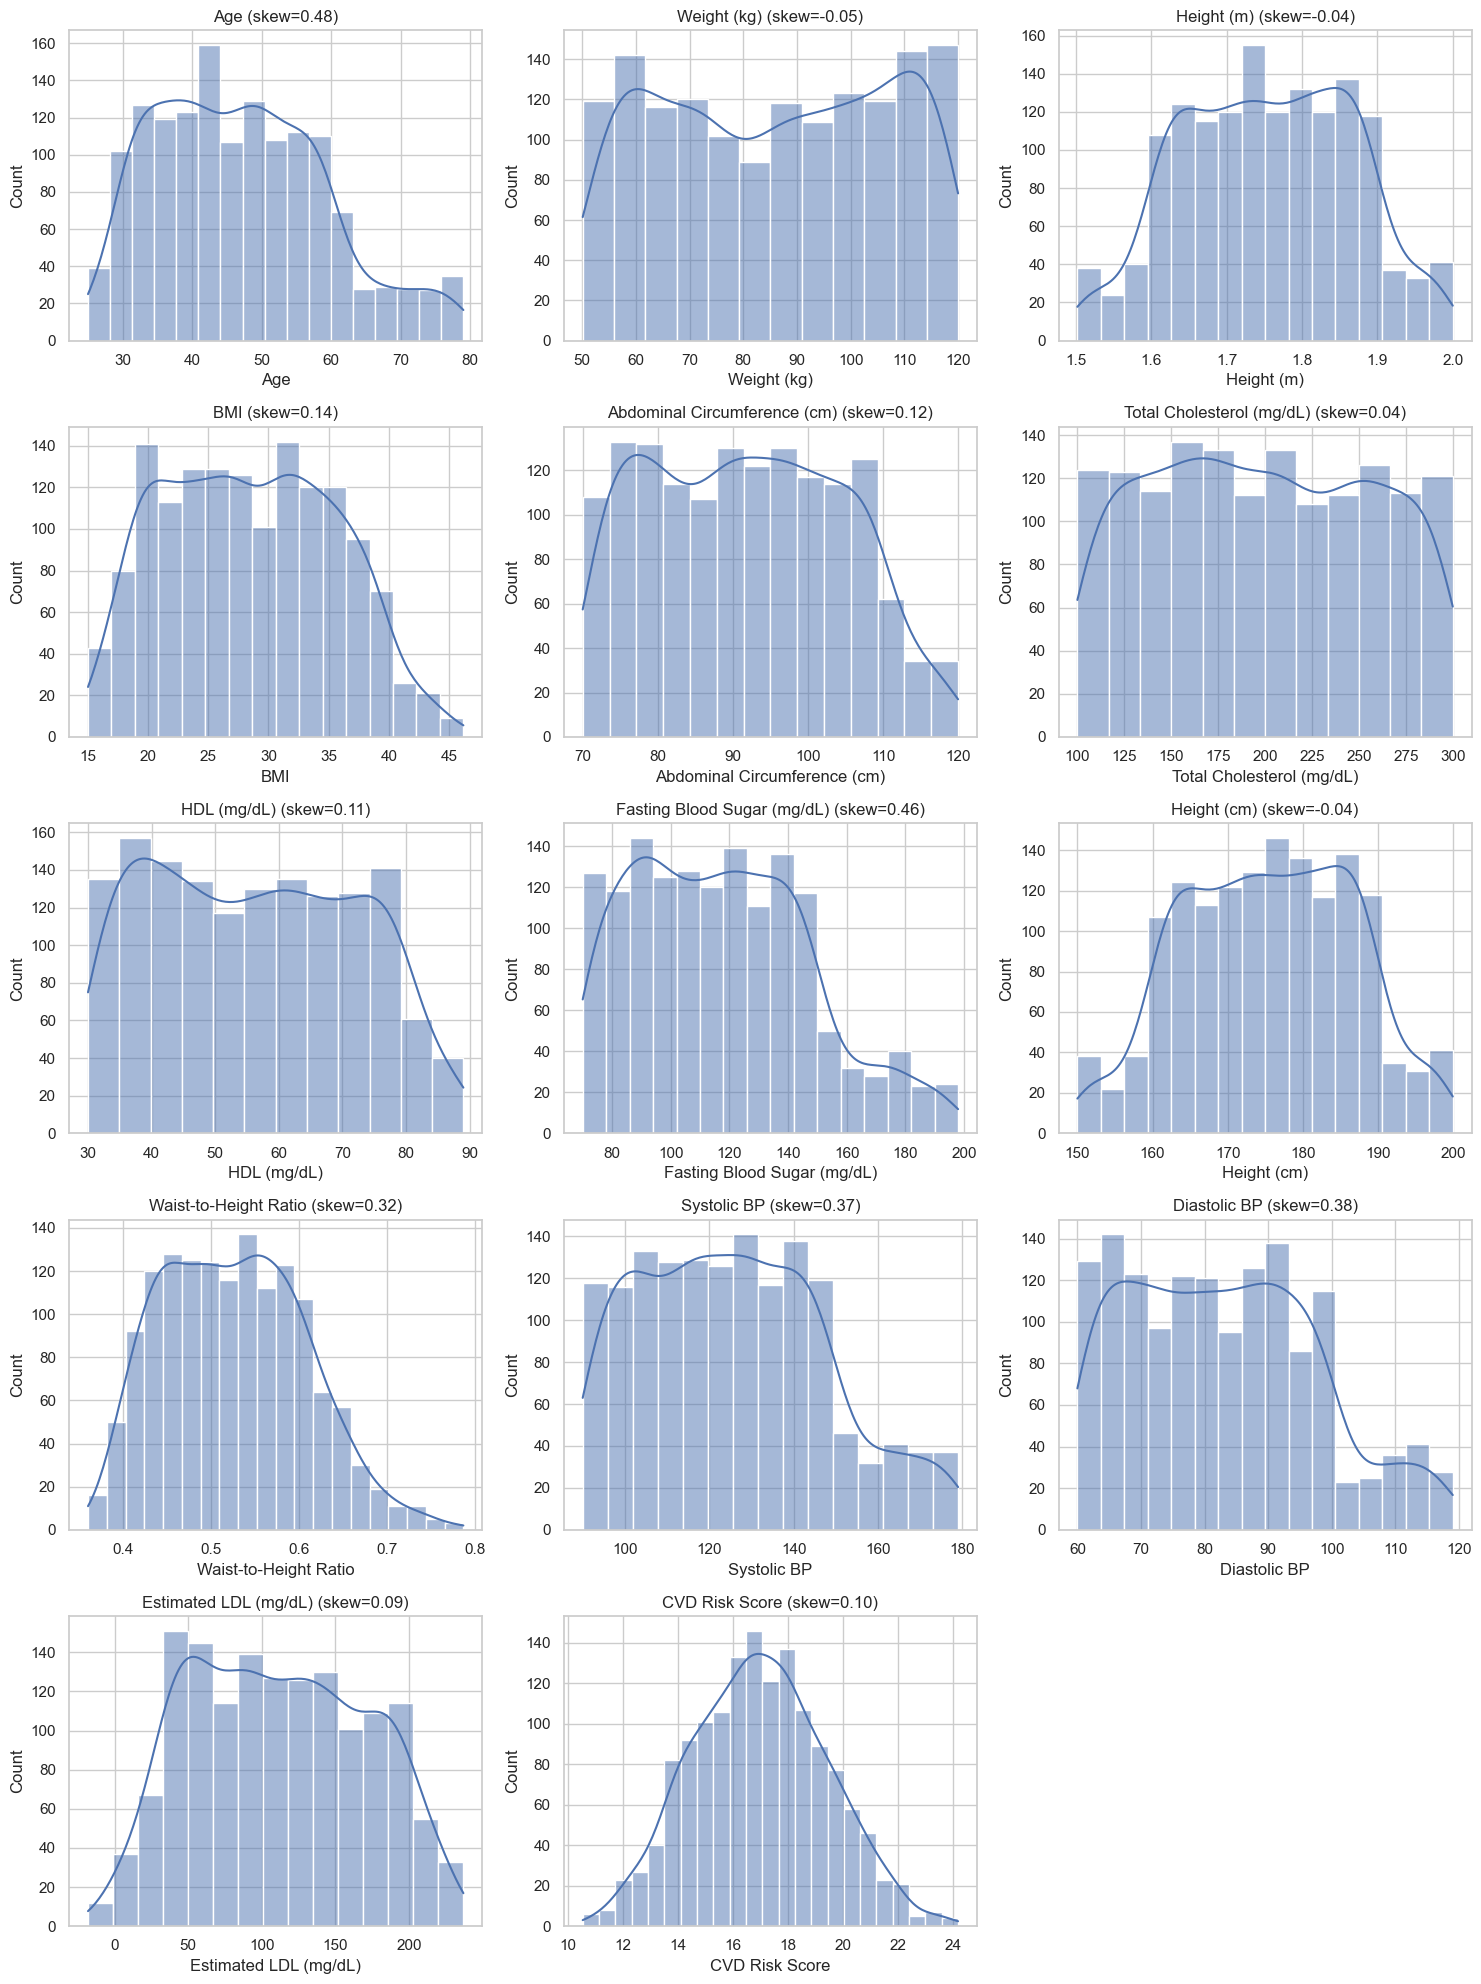

In [7]:
n = len(numeric_cols)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 4 * ((n + 2) // 3)))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col} (skew={df[col].skew():.2f})")
for ax in axes.flatten()[n:]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

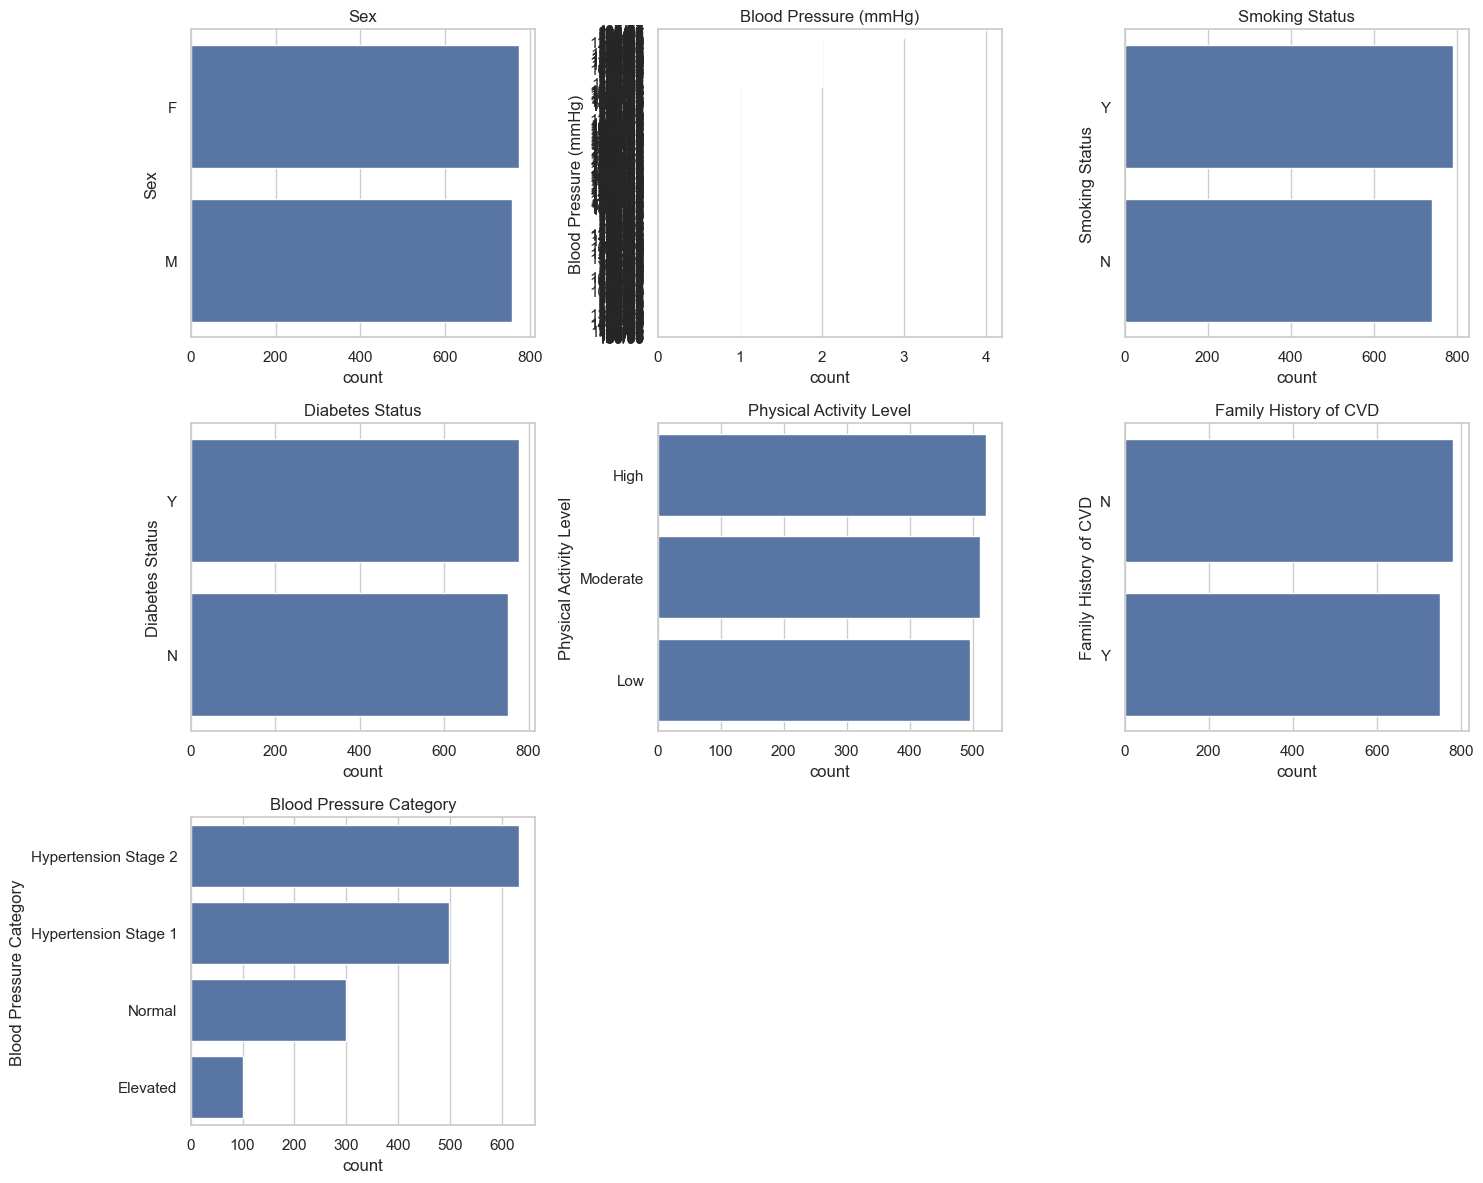

In [8]:
n = len(categorical_cols)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 4 * ((n + 2) // 3)))
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(col)
for ax in axes.flatten()[n:]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

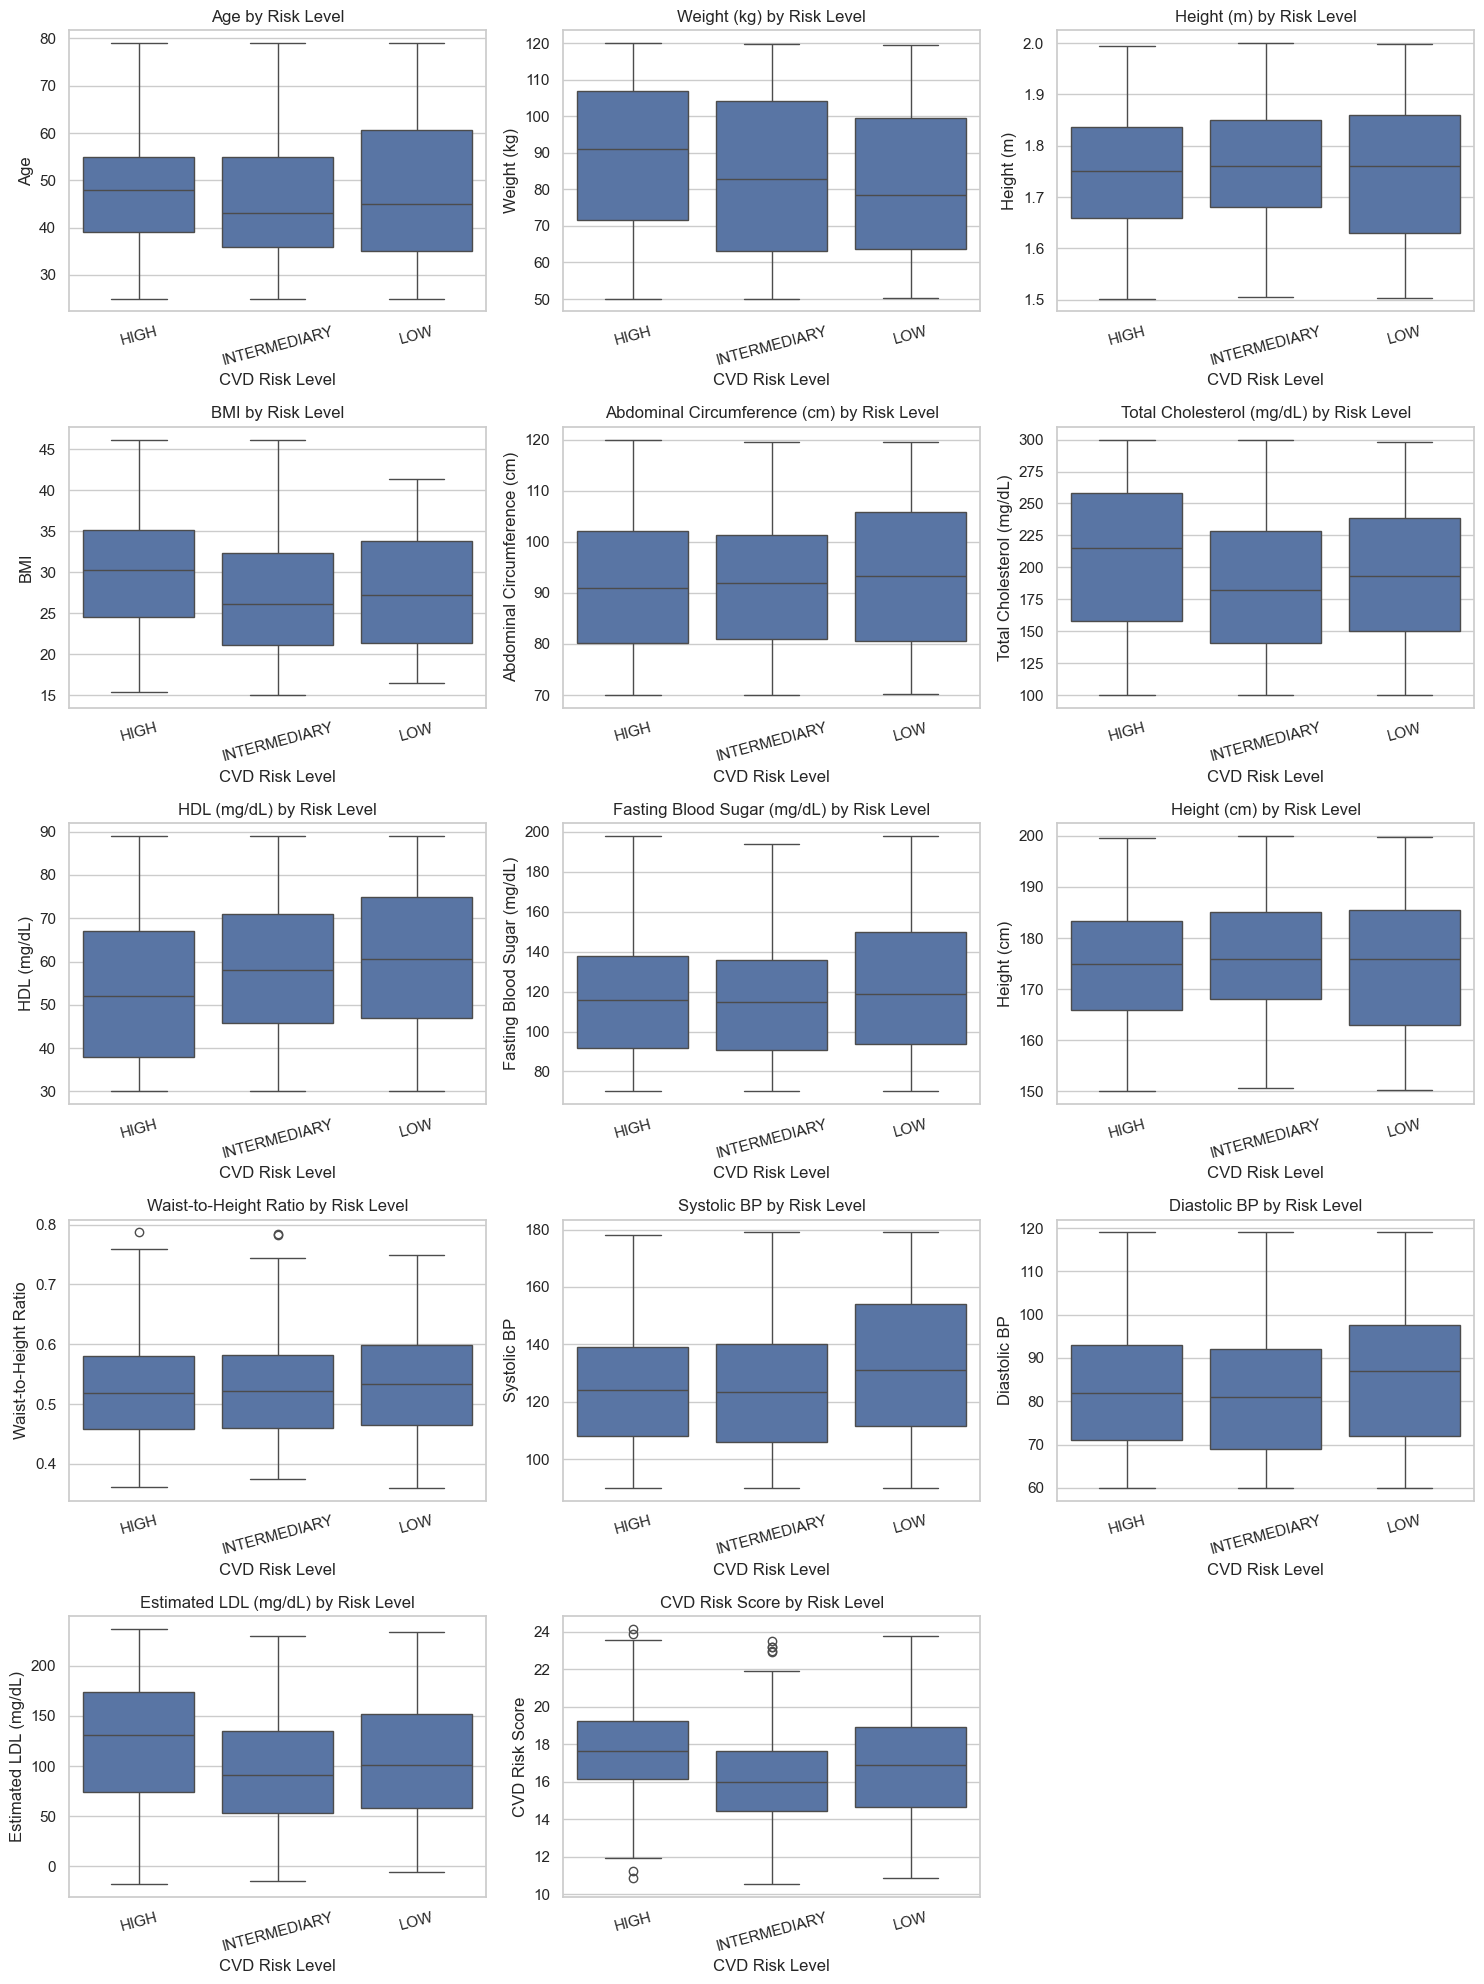

In [9]:
n = len(numeric_cols)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 4 * ((n + 2) // 3)))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df, x=TARGET, y=col, order=order, ax=ax)
    ax.set_title(f"{col} by Risk Level")
    ax.tick_params(axis="x", rotation=15)
for ax in axes.flatten()[n:]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

---
## 3. Data Preparation
*(Author: Shindu)*

### 3.1 Data Selection and Scope Definition

The raw CAIR-CVD-2025 dataset contains 1,529 patient records with 22 columns spanning
demographic, anthropometric, clinical, biochemical, and lifestyle features. Before
modelling, several columns are removed based on findings from Section 2.

Columns dropped and their justification:

- **`Blood Pressure (mmHg)`** — raw text string (e.g. "125/79"); its information is
  already fully captured in the parsed `Systolic BP` and `Diastolic BP` columns
- **`Height (cm)`** — exact duplicate of `Height (m)`, confirmed by a perfect
  correlation of r = 1.00 in Section 2.5
- **`Waist-to-Height Ratio`** — arithmetically derived from `Abdominal Circumference`
  (r = 0.90); retaining both adds no new information to the model
- **`Estimated LDL (mg/dL)`** — derived from `Total Cholesterol` (r = 0.96) and
  contains clinically impossible negative values (minimum −18) identified in Section 2
- **`Blood Pressure Category`** — engineered directly from `Systolic BP` and
  `Diastolic BP`; including it risks encoding target-adjacent information into the
  feature space
- **`CVD Risk Score`** — confirmed in Section 2.3 to carry no meaningful separating
  signal across risk levels; group means were even out of expected order

---

### 3.2 Data Loading and Initial Inspection

We reload the raw dataset and inspect its structure, shape, column data types, and a
sample of records before any transformation is applied. This ensures we have a clean,
unmodified baseline to reference throughout the preparation steps.

The dataset confirms 1,529 records across 22 columns. All categorical columns —
Sex, Smoking Status, Diabetes Status, Physical Activity Level, Family History of CVD,
Blood Pressure Category, and the target CVD Risk Level — are fully complete with no
missing values. The 14 numeric columns each carry a missing rate of approximately
4–5%, with Diastolic BP being the most affected at 5.36% and BMI the least at 4.19%.
This uniform, low-level missingness across numeric columns is consistent with what
was identified in Section 2.1 and confirms that a single simple imputation strategy
is appropriate.

---

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Load raw dataset
DATA_PATH = "CVD Dataset.csv"
df = pd.read_csv(DATA_PATH)

# Basic shape and structure
print("Dataset shape:", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)

# Preview first few rows to confirm data loaded correctly
df.head()

# Summary statistics across all columns before any changes
df.describe(include="all").T

Dataset shape: (1529, 22)

Column names and dtypes:
Sex                              object
Age                             float64
Weight (kg)                     float64
Height (m)                      float64
BMI                             float64
Abdominal Circumference (cm)    float64
Blood Pressure (mmHg)            object
Total Cholesterol (mg/dL)       float64
HDL (mg/dL)                     float64
Fasting Blood Sugar (mg/dL)     float64
Smoking Status                   object
Diabetes Status                  object
Physical Activity Level          object
Family History of CVD            object
CVD Risk Level                   object
Height (cm)                     float64
Waist-to-Height Ratio           float64
Systolic BP                     float64
Diastolic BP                    float64
Blood Pressure Category          object
Estimated LDL (mg/dL)           float64
CVD Risk Score                  float64
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sex,1529,2,F,773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1451.0,NaN,NaN,NaN,47.0255,12.421063,25.0,37.0,46.0,55.0,79.0
Weight (kg),1448.0,NaN,NaN,NaN,85.917427,21.01258,50.1,67.05,86.6145,105.0,120.0
Height (m),1462.0,NaN,NaN,NaN,1.754111,0.11309,1.502,1.66,1.755,1.8455,2.0
BMI,1465.0,NaN,NaN,NaN,28.465997,7.038685,15.0,22.629,28.159,34.0,46.2
Abdominal Circumference (cm),1462.0,NaN,NaN,NaN,91.773214,12.823573,70.0,80.5,91.6,102.269,119.996
Blood Pressure (mmHg),1529,1254,127/84,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Cholesterol (mg/dL),1456.0,NaN,NaN,NaN,198.539148,57.794099,100.0,150.0,197.0,249.0,300.0
HDL (mg/dL),1449.0,NaN,NaN,NaN,56.197378,16.066754,30.0,42.0,56.0,70.0,89.0
Fasting Blood Sugar (mg/dL),1462.0,NaN,NaN,NaN,117.485636,30.289174,70.0,92.0,115.0,138.0,198.0


In [11]:
# Confirm missing values per column before any handling
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
}).query("missing_count > 0").sort_values("missing_count", ascending=False)

print("Columns with missing values:")
print(missing_table)


Columns with missing values:
                              missing_count  missing_%
Diastolic BP                             82       5.36
Weight (kg)                              81       5.30
HDL (mg/dL)                              80       5.23
Waist-to-Height Ratio                    79       5.17
Age                                      78       5.10
Height (cm)                              74       4.84
Total Cholesterol (mg/dL)                73       4.77
Systolic BP                              71       4.64
CVD Risk Score                           70       4.58
Estimated LDL (mg/dL)                    69       4.51
Height (m)                               67       4.38
Abdominal Circumference (cm)             67       4.38
Fasting Blood Sugar (mg/dL)              67       4.38
BMI                                      64       4.19


The dataset loaded successfully with **1,529 records and 22 columns**. Column data
types are as expected — seven columns are stored as `object` (string) type covering
all categorical variables including the target, while the remaining 15 are `float64`
numeric measurements. The summary statistics confirm the following key observations:

- **Age** ranges from 25 to 79 years with a mean of 47.0, reflecting a middle-aged
  adult population
- **BMI** ranges from 15.0 to 46.2, indicating the dataset includes both severely
  underweight and morbidly obese patients
- **Total Cholesterol** ranges from 100 to 300 mg/dL with a mean of 198.5 mg/dL,
  which is within clinically expected bounds
- **Estimated LDL** has a minimum of **−18 mg/dL**, which is clinically impossible
  and confirms the data quality issue flagged in Section 2 — this column will be
  dropped in Section 3.3
- **CVD Risk Level** has 3 unique values with HIGH being the most frequent class,
  consistent with Section 2.2 findings
- All 7 categorical columns are **fully complete** with no missing values
- All 14 numeric columns carry missing values ranging from **4.19% (BMI) to 5.36%
  (Diastolic BP)**, confirming the uniform low-level missingness pattern identified
  in Section 2.1

---

### 3.3 Dropping Redundant and Leakage-Prone Columns

With the raw data confirmed, we remove the six columns identified in Section 3.1.
This reduces the feature space from 22 to 16 columns, retaining only variables that
are non-redundant, non-derived, and appropriate for modelling. The remaining 16
columns consist of the target variable, five categorical predictors, and ten numeric
clinical and anthropometric measurements.

---

In [12]:
# Drop columns identified as redundant or leakage-prone in Section 2 and 3.1
cols_to_drop = [
    "Blood Pressure (mmHg)",    # raw text, already parsed into Systolic/Diastolic BP
    "Height (cm)",              # exact duplicate of Height (m), r = 1.00
    "Waist-to-Height Ratio",    # derived from Abdominal Circumference, r = 0.90
    "Estimated LDL (mg/dL)",    # derived from Total Cholesterol (r = 0.96), contains negatives
    "Blood Pressure Category",  # engineered from BP columns, potential leakage
    "CVD Risk Score"            # no separating signal across risk levels (Section 2.3)
]

df_clean = df.drop(columns=cols_to_drop)

print("Shape before dropping:", df.shape)
print("Shape after dropping: ", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Shape before dropping: (1529, 22)
Shape after dropping:  (1529, 16)

Remaining columns:
['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'CVD Risk Level', 'Systolic BP', 'Diastolic BP']


The six target columns were successfully removed. The dataset shape reduced from
**(1,529 × 22) to (1,529 × 16)**, confirming all six columns were dropped without
affecting any records. The 16 remaining columns are:

- **Demographic:** Sex, Age
- **Anthropometric:** Weight (kg), Height (m), BMI, Abdominal Circumference (cm)
- **Biochemical:** Total Cholesterol (mg/dL), HDL (mg/dL), Fasting Blood Sugar (mg/dL)
- **Clinical:** Systolic BP, Diastolic BP
- **Lifestyle:** Smoking Status, Diabetes Status, Physical Activity Level,
  Family History of CVD
- **Target:** CVD Risk Level

No records were lost in this step — the row count remains 1,529.

---

### 3.4 Handling Missing Values

All ten numeric columns carry approximately 4–5% missingness, which is low and
uniformly distributed across the dataset, as confirmed in Section 2.1. Median
imputation is applied to all numeric columns. This approach is chosen because:

- The missingness rate is small and consistent — no column is disproportionately
  affected
- Median is robust to the mild skewness observed in several distributions in Section 2
- It is straightforward to apply and interpret, and does not risk introducing
  cross-feature assumptions

To verify that imputation did not distort the underlying distributions, column means
are compared before and after. The difference across all ten columns rounds to 0.000,
confirming that filling 4–5% of values with the column median had no meaningful
impact on the data. This is the expected and desired outcome — it validates that the
missing values were randomly distributed and that median imputation was the
appropriate choice.

---

In [13]:
# Identify numeric columns remaining after the drop step
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()

print("Numeric columns to impute:")
print(numeric_cols)
print(f"\nTotal missing cells before imputation: {df_clean[numeric_cols].isna().sum().sum()}")

# Store column means BEFORE imputation for comparison
means_before = df_clean[numeric_cols].mean().round(3)

# Apply median imputation to all numeric columns
for col in numeric_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# Store column means AFTER imputation for comparison
means_after = df_clean[numeric_cols].mean().round(3)

# Confirm no missing values remain
print(f"\nTotal missing cells after imputation: {df_clean.isna().sum().sum()}")
print("\nMissing values per column after imputation:")
print(df_clean.isna().sum())

# Display side-by-side comparison
imputation_check = pd.DataFrame({
    "Mean Before Imputation": means_before,
    "Mean After Imputation":  means_after,
    "Difference":             (means_after - means_before).round(3)
})

print("Mean comparison before and after median imputation:")
print(imputation_check)

Numeric columns to impute:
['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Systolic BP', 'Diastolic BP']

Total missing cells before imputation: 730

Total missing cells after imputation: 0

Missing values per column after imputation:
Sex                             0
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Smoking Status                  0
Diabetes Status                 0
Physical Activity Level         0
Family History of CVD           0
CVD Risk Level                  0
Systolic BP                     0
Diastolic BP                    0
dtype: int64
Mean comparison before and after median imputation:
                              Mean Before Imputation

Prior to imputation, **730 missing cells** were identified across the 10 numeric columns. Following median imputation, the total missing cell count dropped to **0**, confirmed across all 16 columns.

The mean comparison table shows that differences across all ten columns are negligibly small, ranging from **−0.109 (Fasting Blood Sugar)** to **+0.037 (Weight)**. These differences are trivially small relative to each feature's scale and are a natural consequence of the median and mean not being identical statistics. With only 4–5% of values missing per column, replacing missing entries with the column median produces no meaningful shift in the overall distribution. This confirms two things:

- The missing values were **randomly distributed** — no systematic bias in which records had missing data
- **Median imputation was the appropriate strategy** — it resolved all missingness without introducing any distributional distortion
---

### 3.5 Target Variable Transformation

The target column `CVD Risk Level` contains three string classes — LOW, INTERMEDIARY,
and HIGH — which must be converted to numeric form for all three models. An ordinal
encoding is applied that reflects the natural clinical progression of cardiovascular
risk. This is more meaningful than arbitrary label assignment and is applied
consistently across all three models in Section 4.

| Original Label | Encoded Value |
|---|---|
| LOW | 0 |
| INTERMEDIARY | 1 |
| HIGH | 2 |

---

In [14]:
# Ordinal encoding reflecting clinical risk progression
risk_mapping = {
    "LOW": 0,
    "INTERMEDIARY": 1,
    "HIGH": 2
}

df_clean["CVD Risk Level"] = df_clean["CVD Risk Level"].map(risk_mapping)

# Confirm encoding and class counts
print("Target value counts after encoding:")
print(df_clean["CVD Risk Level"].value_counts().sort_index())
print("\nEncoding applied:", risk_mapping)

Target value counts after encoding:
CVD Risk Level
0    220
1    581
2    728
Name: count, dtype: int64

Encoding applied: {'LOW': 0, 'INTERMEDIARY': 1, 'HIGH': 2}


The ordinal encoding was applied successfully. The class counts after encoding are:

| Encoded Value | Risk Level | Count |
|---|---|---|
| 0 | LOW | 220 |
| 1 | INTERMEDIARY | 581 |
| 2 | HIGH | 728 |

These counts are consistent with the class distribution confirmed in Section 2.2,
with **HIGH** being the majority class at 47.6%, **INTERMEDIARY** at 38.0%, and
**LOW** as the minority class at 14.4%. No records were lost or misassigned during
the mapping — the total remains 1,529.

---

### 3.6 Feature Encoding

The remaining categorical predictor columns are converted to numeric form using
direct mapping. No one-hot encoding is required because there are no unordered
multi-class nominal features — all categoricals are either binary or naturally
ordered.

| Feature | Type | Encoding |
|---|---|---|
| Sex | Binary nominal | M = 1, F = 0 |
| Smoking Status | Binary | Y = 1, N = 0 |
| Diabetes Status | Binary | Y = 1, N = 0 |
| Family History of CVD | Binary | Y = 1, N = 0 |
| Physical Activity Level | Ordinal | Low = 0, Moderate = 1, High = 2 |

Physical Activity Level is treated as ordinal because it has a meaningful natural
order — a higher activity level represents a clinically distinct and progressively
better health behaviour. Encoding it as 0, 1, 2 preserves this relationship, which
all three models can exploit during training.

Following encoding, all 16 columns in the cleaned dataset are confirmed as numeric,
with no object-type columns remaining. The dataset is fully prepared for feature
separation and splitting.

---

In [15]:
# Binary encoding for yes/no and sex columns
binary_mappings = {
    "Sex":                   {"M": 1, "F": 0},
    "Smoking Status":        {"Y": 1, "N": 0},
    "Diabetes Status":       {"Y": 1, "N": 0},
    "Family History of CVD": {"Y": 1, "N": 0}
}

for col, mapping in binary_mappings.items():
    df_clean[col] = df_clean[col].map(mapping)
    print(f"  {col}: {mapping}")

  Sex: {'M': 1, 'F': 0}
  Smoking Status: {'Y': 1, 'N': 0}
  Diabetes Status: {'Y': 1, 'N': 0}
  Family History of CVD: {'Y': 1, 'N': 0}


In [16]:
# Ordinal encoding for Physical Activity Level
activity_mapping = {"Low": 0, "Moderate": 1, "High": 2}
df_clean["Physical Activity Level"] = df_clean["Physical Activity Level"].map(activity_mapping)

print("Physical Activity Level encoded:", activity_mapping)

Physical Activity Level encoded: {'Low': 0, 'Moderate': 1, 'High': 2}


In [17]:
# Confirm all columns are now numeric and inspect encoded dataset
print("\nData types after encoding:")
print(df_clean.dtypes)

print("\nSample of fully encoded dataset:")
df_clean.head()


Data types after encoding:
Sex                               int64
Age                             float64
Weight (kg)                     float64
Height (m)                      float64
BMI                             float64
Abdominal Circumference (cm)    float64
Total Cholesterol (mg/dL)       float64
HDL (mg/dL)                     float64
Fasting Blood Sugar (mg/dL)     float64
Smoking Status                    int64
Diabetes Status                   int64
Physical Activity Level           int64
Family History of CVD             int64
CVD Risk Level                    int64
Systolic BP                     float64
Diastolic BP                    float64
dtype: object

Sample of fully encoded dataset:


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,CVD Risk Level,Systolic BP,Diastolic BP
0,0,32.0,69.1000,1.71,23.6,86.2,248.0,78.0,111.0,0,1,0,0,1,125.0,79.0
1,0,55.0,118.7000,1.69,41.6,82.5,162.0,50.0,135.0,1,1,2,1,2,139.0,70.0
2,1,46.0,86.6145,1.83,26.9,106.7,103.0,73.0,114.0,0,0,2,1,1,104.0,77.0
3,1,44.0,108.3000,1.80,33.4,96.6,134.0,46.0,91.0,0,0,2,1,1,140.0,83.0
4,0,32.0,99.5000,1.86,28.8,102.7,146.0,64.0,141.0,1,1,2,0,1,144.0,83.0


All five categorical predictor columns were successfully encoded to numeric form.
The data type confirmation shows that **Sex, Smoking Status, Diabetes Status,
Physical Activity Level, and Family History of CVD** are now stored as `int64`,
while the remaining numeric measurements remain as `float64`. No `object` type
columns remain in the dataset — the full feature space is numeric and ready for
modelling.

The sample output of the encoded dataset confirms the mappings are correct — for
example, row 0 shows **Sex = 0 (Female)**, **Smoking Status = 0 (Non-smoker)**,
**Diabetes Status = 1 (Diabetic)**, and **Physical Activity Level = 0 (Low)**,
which is consistent with the original raw values for that record.

---

### 3.7 Feature and Target Separation

With all transformations applied, the dataset is separated into the feature matrix X
and the target vector y. X contains 15 predictor columns and y contains the encoded
CVD Risk Level. This separation is performed before the train/test split to ensure
the target is handled consistently throughout.

---

In [18]:
TARGET = "CVD Risk Level"

# Separate predictors and target
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print("Feature matrix shape:", X.shape)
print("Target vector shape: ", y.shape)
print("\nFeatures entering modelling:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

Feature matrix shape: (1529, 15)
Target vector shape:  (1529,)

Features entering modelling:
   1. Sex
   2. Age
   3. Weight (kg)
   4. Height (m)
   5. BMI
   6. Abdominal Circumference (cm)
   7. Total Cholesterol (mg/dL)
   8. HDL (mg/dL)
   9. Fasting Blood Sugar (mg/dL)
  10. Smoking Status
  11. Diabetes Status
  12. Physical Activity Level
  13. Family History of CVD
  14. Systolic BP
  15. Diastolic BP


The feature matrix **X** contains **1,529 rows and 15 columns**, and the target
vector **y** contains **1,529 labels**. The 15 features entering modelling are:

| # | Feature | Type |
|---|---|---|
| 1 | Sex | Binary |
| 2 | Age | Continuous |
| 3 | Weight (kg) | Continuous |
| 4 | Height (m) | Continuous |
| 5 | BMI | Continuous |
| 6 | Abdominal Circumference (cm) | Continuous |
| 7 | Total Cholesterol (mg/dL) | Continuous |
| 8 | HDL (mg/dL) | Continuous |
| 9 | Fasting Blood Sugar (mg/dL) | Continuous |
| 10 | Smoking Status | Binary |
| 11 | Diabetes Status | Binary |
| 12 | Physical Activity Level | Ordinal |
| 13 | Family History of CVD | Binary |
| 14 | Systolic BP | Continuous |
| 15 | Diastolic BP | Continuous |

---

### 3.8 Train/Test Split

The dataset is split into 80% training (1,223 rows) and 20% test (306 rows) sets.
Stratification on the target variable is applied to ensure that the class
proportions — particularly the minority LOW class at 14.4% — are preserved in both
splits. An unrepresentative split could distort both training signal and evaluation
metrics, which is especially problematic given the class imbalance identified in
Section 2.2.

The visualisation confirms that the proportions of LOW, INTERMEDIARY, and HIGH are
consistent across both sets. The training set contains 176 LOW, 465 INTERMEDIARY, and
582 HIGH records. The test set contains 44 LOW, 116 INTERMEDIARY, and 146 HIGH
records. Both sets reflect the same approximate ratio of 14 : 38 : 48, confirming
that stratification was successful.

---

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # preserve LOW/INTERMEDIARY/HIGH proportions in both sets
)

print(f"Training set : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution — Training set:")
print(y_train.value_counts().sort_index().rename({0:"LOW", 1:"INTERMEDIARY", 2:"HIGH"}))

print("\nClass distribution — Test set:")
print(y_test.value_counts().sort_index().rename({0:"LOW", 1:"INTERMEDIARY", 2:"HIGH"}))

Training set : 1223 rows (80.0%)
Test set     : 306 rows (20.0%)

Class distribution — Training set:
CVD Risk Level
LOW             176
INTERMEDIARY    465
HIGH            582
Name: count, dtype: int64

Class distribution — Test set:
CVD Risk Level
LOW              44
INTERMEDIARY    116
HIGH            146
Name: count, dtype: int64


To confirm that stratification preserved class proportions visually, we plot the class distribution across the training and test sets side by side. A well-stratified split should show near-identical proportions in both sets, ensuring neither the model training nor its evaluation is skewed by an unrepresentative sample.

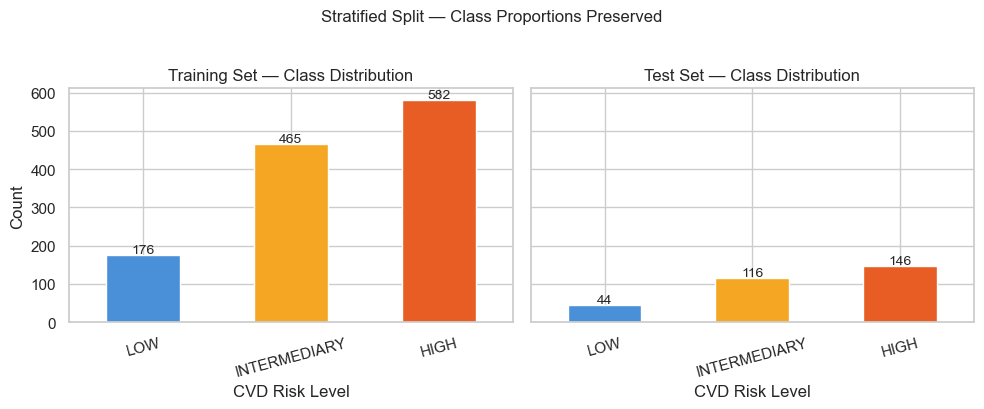

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Training set distribution
train_counts = y_train.value_counts().sort_index()
train_counts.index = ["LOW", "INTERMEDIARY", "HIGH"]
train_counts.plot(kind="bar", ax=axes[0], color=["#4A90D9", "#F5A623", "#E85D24"],
                  edgecolor="white")
axes[0].set_title("Training Set — Class Distribution")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("CVD Risk Level")
axes[0].tick_params(axis="x", rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                     ha="center", fontsize=10)

# Test set distribution
test_counts = y_test.value_counts().sort_index()
test_counts.index = ["LOW", "INTERMEDIARY", "HIGH"]
test_counts.plot(kind="bar", ax=axes[1], color=["#4A90D9", "#F5A623", "#E85D24"],
                 edgecolor="white")
axes[1].set_title("Test Set — Class Distribution")
axes[1].set_xlabel("CVD Risk Level")
axes[1].tick_params(axis="x", rotation=15)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                     ha="center", fontsize=10)

plt.suptitle("Stratified Split — Class Proportions Preserved", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The stratified split produced a **training set of 1,223 rows (80.0%)** and a
**test set of 306 rows (20.0%)**. The class distributions across both sets confirm
that stratification was successful:

| Risk Level | Training Count | Test Count |
|---|---|---|
| LOW (0) | 176 | 44 |
| INTERMEDIARY (1) | 465 | 116 |
| HIGH (2) | 582 | 146 |

Both sets maintain the same approximate ratio of **14 : 38 : 48** across LOW,
INTERMEDIARY, and HIGH respectively. The bar chart confirms this visually — the
relative heights of the three bars are proportionally consistent between the
training and test panels. The minority LOW class is preserved in both sets,
which is critical for ensuring the model is evaluated fairly on all three classes
in Section 4.

---

### 3.9 Feature Scaling

Feature scaling is applied selectively based on model requirements. Random Forest is
a tree-based algorithm that makes decisions based on feature split thresholds — it is
invariant to the absolute magnitude of feature values and does not benefit from
scaling. Logistic Regression and KNN are both sensitive to feature scale; without
standardisation, features measured in larger units such as Total Cholesterol
(mg/dL) or Fasting Blood Sugar (mg/dL) would disproportionately influence model
behaviour.

The scaler is fitted exclusively on the training set and then applied to the test
set. Fitting on the full dataset before splitting would allow test set statistics to
influence the training transformation, constituting data leakage.

| Model | Scaling Required | Reason |
|---|---|---|
| Random Forest | No | Tree splits are scale-invariant |
| Logistic Regression | Yes | Sensitive to feature magnitude; affects convergence |
| KNN | Yes | Distance-based; large-scale features dominate similarity |

After scaling, the training set statistics confirm that all 15 features have a mean
of approximately 0 and a standard deviation of 1, as expected from StandardScaler.
The same transformation is applied to the test set using the training set parameters
only.

---

In [21]:
scaler = StandardScaler()

# Fit on training data only — never on test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Scaling complete — StandardScaler fitted on training set only.")
print(f"\nX_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")
print("\nTraining set statistics after scaling:")
X_train_scaled.describe().round(3)

Scaling complete — StandardScaler fitted on training set only.

X_train_scaled shape : (1223, 15)
X_test_scaled shape  : (306, 15)

Training set statistics after scaling:


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Systolic BP,Diastolic BP
count,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000,1223.000
mean,-0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.967,-1.816,-1.739,-2.303,-1.931,-1.763,-1.757,-1.681,-1.583,-1.017,-1.024,-1.260,-0.985,-1.648,-1.593
25%,-0.967,-0.817,-0.894,-0.763,-0.800,-0.856,-0.849,-0.850,-0.815,-1.017,-1.024,-1.260,-0.985,-0.773,-0.823
50%,-0.967,-0.067,0.040,0.016,-0.023,-0.013,-0.030,-0.019,-0.080,0.983,0.977,-0.027,-0.985,-0.036,-0.053
75%,1.034,0.682,0.895,0.795,0.766,0.805,0.860,0.876,0.688,0.983,0.977,1.206,1.016,0.655,0.647
max,1.034,2.681,1.667,2.262,2.578,2.278,1.804,2.090,2.691,0.983,0.977,1.206,1.016,2.452,2.537


Scaling completed successfully with the StandardScaler fitted on the training set
only. Both the scaled training set (**X_train_scaled**) and scaled test set
(**X_test_scaled**) contain **15 features**, with shapes of **(1,223 × 15)** and
**(306 × 15)** respectively.

The post-scaling statistics for the training set confirm correct standardisation:

- **Mean ≈ 0.000** across all 15 features, confirming the scaler centred each
  feature around zero
- **Standard deviation = 1.000** across all 15 features, confirming unit variance
  was achieved

These properties ensure that no single feature dominates the distance calculations
in KNN or the coefficient magnitudes in Logistic Regression due to differences in
measurement scale. The unscaled **X_train** and **X_test** are preserved separately
for Random Forest, which does not require this transformation.

---


### 3.10 Final Data Preparation Summary

All preparation steps are complete. The dataset has been reduced from 22 to 16
columns, missing values have been resolved through median imputation, all features
are numeric and appropriately encoded, and the data has been split and scaled. Two
dataset variants are carried forward into Section 4 — unscaled for Random Forest,
and scaled for Logistic Regression and KNN. The k-value for KNN will be tuned during
modelling in Section 4.

In [22]:
# Save cleaned and encoded dataset for reference
df_clean.to_csv("CVD_Dataset_Cleaned.csv", index=False)
print("Cleaned dataset saved as CVD_Dataset_Cleaned.csv")

print("=" * 55)
print("        DATA PREPARATION SUMMARY")
print("=" * 55)
print(f"  Original dataset shape     : {df.shape}")
print(f"  After dropping columns     : {df_clean.shape}")
print(f"  Missing values remaining   : {df_clean.isna().sum().sum()}")
print(f"  Features for modelling     : {X.shape[1]}")
print(f"  Training samples           : {X_train.shape[0]}")
print(f"  Test samples               : {X_test.shape[0]}")
print(f"  Target encoding            : LOW=0, INTERMEDIARY=1, HIGH=2")
print(f"  Imputation method          : Median (all numeric columns)")
print("=" * 55)
print("  DATA ROUTING TO MODELS")
print("=" * 55)
print(f"  Random Forest              : X_train,        X_test")
print(f"  Logistic Regression        : X_train_scaled, X_test_scaled")
print(f"  KNN                        : X_train_scaled, X_test_scaled")
print("=" * 55)
print("  Note: Scaler fitted on training set only.")
print("  KNN k-value to be tuned in Section 4.")
print("=" * 55)
print("  Data is ready for modelling.")
print("=" * 55)

Cleaned dataset saved as CVD_Dataset_Cleaned.csv
        DATA PREPARATION SUMMARY
  Original dataset shape     : (1529, 22)
  After dropping columns     : (1529, 16)
  Missing values remaining   : 0
  Features for modelling     : 15
  Training samples           : 1223
  Test samples               : 306
  Target encoding            : LOW=0, INTERMEDIARY=1, HIGH=2
  Imputation method          : Median (all numeric columns)
  DATA ROUTING TO MODELS
  Random Forest              : X_train,        X_test
  Logistic Regression        : X_train_scaled, X_test_scaled
  KNN                        : X_train_scaled, X_test_scaled
  Note: Scaler fitted on training set only.
  KNN k-value to be tuned in Section 4.
  Data is ready for modelling.


The preparation summary confirms the dataset is fully ready for modelling with the
following key facts:

- **730 missing cells** resolved — **0 remaining**
- Dataset reduced from **22 columns to 16**, with **15 features** entering modelling
- **1,223 training samples** and **306 test samples**, stratified across all three
  classes
- Target encoded as **LOW = 0, INTERMEDIARY = 1, HIGH = 2**
- **Two data variants** prepared and clearly routed:
  - `X_train` / `X_test` → **Random Forest**
  - `X_train_scaled` / `X_test_scaled` → **Logistic Regression** and **KNN**
- Cleaned dataset saved as **CVD_Dataset_Cleaned.csv** for reference
- KNN **k-value tuning** is deferred to Section 4 where cross-validation will
  determine the optimal number of neighbours

---
## 4. Modelling
*(Author: Rakib)*

### 4.1 Model Selection Rationale

For the multi-class risk prediction on our updated CAIR-CVD dataset, we evaluated the suitability of several algorithms for clinical tabular data. We selected **two models** to carry forward:

---

#### 4.1.1 Logistic Regression — Baseline Model

Logistic regression is the industry standard baseline for medical classification studies. It is highly transparent, directly showing the relationship between risk factors and disease probability.

**Why chosen:**
- Extends naturally to multi-class problems (using One-vs-Rest or Multinomial approaches).
- Outputs probability scores natively, supporting the risk-tier output described in Section 6.
- Coefficients are directly interpretable by clinicians (showing how much each feature increases or decreases risk).
- Serves as a transparent baseline against which more complex models can be compared.

---

#### 4.1.2 Random Forest Classifier — Primary Model

Random Forest handles the non-linear, interaction-heavy nature of clinical data. For example, high cholesterol may be a large risk factor for an older patient but a smaller risk for a younger patient — a relationship a linear model might miss.

**Why chosen:**
- Inherently robust generalisation for tabular datasets.
- Naturally handles multi-class classification without needing multiple binary classifiers.
- Resistant to outliers through ensemble averaging.
- Provides feature importance scores — directly supporting the clinical interpretability goal in Section 1.3.
- Less sensitive to feature scaling than Logistic Regression.

---

**Why not SVM or Neural Networks?**
SVMs can be less stable on tabular clinical data and lack native probability outputs. Neural Networks are viable but considerably more complex to tune and interpret. For clinical applications where interpretability is as important as accuracy, well-calibrated tree ensembles like Random Forest and transparent linear models like Logistic Regression are preferable.

### 4.2 Hyperparameter Tuning Strategy

To ensure a fair and rigorous comparison between our models, we employ a consistent hyperparameter tuning strategy:
- **GridSearchCV**: We test a predefined grid of hyperparameters to find the optimal combination for each model.
- **StratifiedKFold (5 splits)**: Because our dataset has a class imbalance (the LOW risk class is a minority), we use stratified cross-validation. This guarantees that every training fold has the exact same proportion of LOW, INTERMEDIARY, and HIGH risk patients, preventing biased learning.
- **Scoring (f1_macro)**: The grid search evaluates models based on the macro-F1 score, ensuring the minority class is given equal weight during tuning.

### 4.3 Logistic Regression

#### 4.3.1 Model Description & Parameters

Hyperparameter tuning was performed using **GridSearchCV** over **15 candidate combinations** evaluated across **5 stratified folds**, resulting in **75 model fits**. The parameters searched and their purpose are summarised below:

| Hyperparameter | Values Searched | Purpose |
|---|---|---|
| `penalty` | `l1`, `l2` | Regularization type — `l1` (Lasso) enables automatic feature selection by shrinking noisy coefficients to exactly zero, while `l2` (Ridge) prevents overfitting by shrinking all coefficients proportionally |
| `C` | 0.01, 0.1, 1, 10, 100 | Inverse of regularization strength — smaller values specify stronger penalty, preventing overfitting and handling multicollinearity |
| `solver` | `lbfgs`, `liblinear` | Optimization algorithm — `lbfgs` minimizes full multinomial loss natively, while `liblinear` is evaluated using One-vs-Rest (OvR) strategy to test if its feature selection capabilities yield better performance on this dataset |
| `max_iter` | 2000 | Maximum iterations — ensures convergence for scaled gradient descent calculations |

Three deliberate design choices were applied:
- **`class_weight='balanced'`** — compensates for the LOW class minority identified in Section 3.5 by penalizing those misclassifications more heavily
- **`StratifiedKFold`** — preserves class proportions in every cross-validation fold
- **Automatic Multinomial Detection** — newer versions of Scikit-Learn natively recognize the 3 target classes and automatically apply multinomial probability calculations without needing an explicit parameter

The output reports the best hyperparameter combination and its cross-validated macro-F1, representing the model's estimated performance.


#### 4.3.2 Code Implementation

In [23]:
# Logistic Regression Imports
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score

RANDOM_STATE = 42
CLASS_NAMES  = ['LOW', 'INTERMEDIARY', 'HIGH']

print('Logistic Regression Modelling...')
print(f'Training set (scaled) : {X_train_scaled.shape} | Test set (scaled): {X_test_scaled.shape}')

# Hyperparameter Tuning
lr_param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs'],
        'max_iter': [2000]
    },
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'],
        'max_iter': [2000]
    }
]

lr_base = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE
)

cv_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_grid = GridSearchCV(
    estimator  = lr_base,
    param_grid = lr_param_grid,
    cv         = cv_lr,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)

lr_grid.fit(X_train_scaled, y_train)

print('\nBest LR parameters:')
for k, v in lr_grid.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV macro-F1: {lr_grid.best_score_:.4f}')



Logistic Regression Modelling...
Training set (scaled) : (1223, 15) | Test set (scaled): (306, 15)
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best LR parameters:
  C: 0.1
  max_iter: 2000
  penalty: l1
  solver: liblinear

Best CV macro-F1: 0.5318


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


### 4.4 Random Forest Classifier

#### 4.4.1 Model Description & Parameters

Hyperparameter tuning was performed using **GridSearchCV** over **216 candidate combinations** (3 × 4 × 3 × 3 × 2) evaluated across **5 stratified folds**, resulting in **1,080 model fits**. The parameters searched and their purpose are summarised below:

| Hyperparameter | Values Searched | Purpose |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Number of trees — more trees improve stability |
| `max_depth` | 5, 10, 15, None | Tree depth — smaller values prevent overfitting |
| `min_samples_split` | 2, 5, 10 | Minimum samples to split a node |
| `min_samples_leaf` | 1, 2, 4 | Minimum samples at a leaf — regularisation constraint |
| `max_features` | `sqrt`, `log2` | Features considered per split — controls tree diversity |

Three deliberate design choices were applied:
- **`class_weight='balanced'`** — compensates for the LOW class minority (14.4%) identified in Section 3.5
- **`scoring='f1_macro'`** — weights all three classes equally, ensuring LOW is not marginalised by the larger HIGH class
- **`StratifiedKFold`** — preserves class proportions in every fold

The output reports the best hyperparameter combination and its cross-validated macro-F1, representing the model's estimated performance before evaluation on the held-out test set.

#### 4.4.2 Code Implementation

In [24]:
# Modelling Imports
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, roc_curve,
                              accuracy_score, precision_score, recall_score,
                              ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
CLASS_NAMES  = ['LOW', 'INTERMEDIARY', 'HIGH']   # LOW=0, INTERMEDIARY=1, HIGH=2

# RF uses unscaled data (tree-based — scale-invariant)
print('Modelling imports loaded.')
print(f'Training set : {X_train.shape} | Test set: {X_test.shape}')
print(f'Target encoding: {dict(enumerate(CLASS_NAMES))}')

# Hyperparameter Tuning
rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_grid = GridSearchCV(
    estimator  = rf_base,
    param_grid = rf_param_grid,
    cv         = cv,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)

rf_grid.fit(X_train, y_train)

print('Best RF parameters:')
for k, v in rf_grid.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV macro-F1: {rf_grid.best_score_:.4f}')

Modelling imports loaded.
Training set : (1223, 15) | Test set: (306, 15)
Target encoding: {0: 'LOW', 1: 'INTERMEDIARY', 2: 'HIGH'}
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best RF parameters:
  max_depth: 10
  max_features: sqrt
  min_samples_leaf: 4
  min_samples_split: 10
  n_estimators: 100

Best CV macro-F1: 0.5781


### 4.5 Best Model Predictions

The best estimators identified during the GridSearchCV phase are now applied to the held-out test set (20% of data). This generates an unbiased evaluation of each model's true clinical performance on unseen patients.

The resulting classification reports provide three critical perspectives on model performance:

| Evaluation Metric | Purpose / Clinical Significance |
|---|---|
| **Class-Level Metrics** | Precision, Recall, and F1-score are reported for each specific risk tier (LOW, INTERMEDIARY, HIGH). This is vital to ensure the model isn't just blindly guessing the majority class. |
| **Macro-F1 Score** | The harmonic mean of Precision and Recall calculated across all classes equally. This is the primary indicator of balanced multi-class performance. |
| **ROC-AUC (One-vs-Rest)** | Measures the model's overall statistical ability to correctly separate and rank patients across all severity levels without bias. |


#### 4.5.1 Logistic Regression Predictions

In [25]:
# Best Model Predictions
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(X_test_scaled)
lr_prob = lr_best.predict_proba(X_test_scaled)

print('\n=== Logistic Regression — Test Set Results ===\n')
print(classification_report(y_test, lr_pred, target_names=CLASS_NAMES))
print(f'Macro-F1 : {f1_score(y_test, lr_pred, average="macro"):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, lr_prob, multi_class="ovr", average="macro"):.4f}')


=== Logistic Regression — Test Set Results ===

              precision    recall  f1-score   support

         LOW       0.21      0.14      0.16        44
INTERMEDIARY       0.62      0.62      0.62       116
        HIGH       0.71      0.77      0.74       146

    accuracy                           0.62       306
   macro avg       0.51      0.51      0.51       306
weighted avg       0.60      0.62      0.61       306

Macro-F1 : 0.5070
ROC-AUC  : 0.7299


#### 4.5.2 Random Forest Predictions

In [26]:
# Best Model Predictions
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_prob = rf_best.predict_proba(X_test)

print('=== Random Forest — Test Set Results ===\n')
print(classification_report(y_test, rf_pred, target_names=CLASS_NAMES))
print(f'Macro-F1 : {f1_score(y_test, rf_pred, average="macro"):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf_prob, multi_class="ovr", average="macro"):.4f}')

=== Random Forest — Test Set Results ===

              precision    recall  f1-score   support

         LOW       0.28      0.27      0.28        44
INTERMEDIARY       0.61      0.59      0.60       116
        HIGH       0.72      0.75      0.73       146

    accuracy                           0.62       306
   macro avg       0.54      0.54      0.54       306
weighted avg       0.61      0.62      0.62       306

Macro-F1 : 0.5355
ROC-AUC  : 0.7897


---
## 5. Evaluation
*(Authors: Rakib, Hajar)*

### 5.1 Evaluation Metrics

Following the evaluation framework, we assess both models using the following metrics:

Because our dataset classifies patients into three risk levels (LOW, INTERMEDIARY, HIGH), we use multi-class evaluation metrics:

- **Accuracy**: The overall proportion of patients correctly classified into their exact risk level.
- **Macro Precision**: The average precision across all three classes, treating each class equally.
- **Macro Recall**: The average recall across all three classes. This ensures the model's ability to find patients is evaluated fairly across the minority (LOW) and majority (HIGH) classes.
- **Macro F1-Score**: The harmonic mean of Macro Precision and Macro Recall, providing a balanced overall performance metric.
- **Class-Specific Recall (LOW, INTERMEDIARY, HIGH)**: The proportion of actual patients in each specific risk tier that the model successfully identified.
- **ROC-AUC (Macro)**: Measures the model's ability to correctly rank patients by risk confidence.

> **Clinical justification for prioritising recall:** A false negative (missed diagnosis) sends a sick patient home untreated — a potentially fatal error. A false positive merely triggers additional confirmatory tests. Therefore, sensitivity/recall is our primary success metric, with the target of ≥ 75% set in Section 1.3.

> **Note on benchmark charts:** The UCI benchmark plots shown in Section 4.1 display **accuracy** ranges. Our primary evaluation focus is **recall**, which may differ from accuracy. We report both.

### 5.2 Confusion Matrices

The confusion matrix provides a complete breakdown of all **306 test predictions** across the three risk classes. Each row represents the **actual** risk level of the patient, and each column represents the **predicted** risk level assigned by the model:

- **Diagonal cells** (top-left to bottom-right) show correctly classified patients for each class — a larger diagonal relative to off-diagonal values indicates better discrimination
- **Off-diagonal cells** show misclassifications — for example, the cell at row LOW, column INTERMEDIARY shows patients who are truly LOW risk but were predicted as INTERMEDIARY
- **Clinically, the most critical error** is any misclassification that places a HIGH risk patient into a lower category, as this corresponds to a false negative for the most severe class

The colour intensity of each cell scales with count — darker blue cells indicate higher concentrations of predictions. A well-performing model will show the darkest shading concentrated along the diagonal, with progressively lighter cells moving away from it.

#### 5.2.1 Logistic Regression



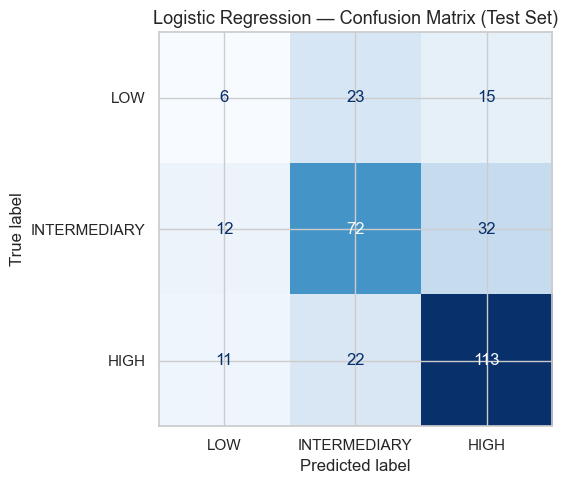

In [27]:
# Confusion Matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(7, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=CLASS_NAMES)
disp_lr.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

#### 5.2.2 Random Forest

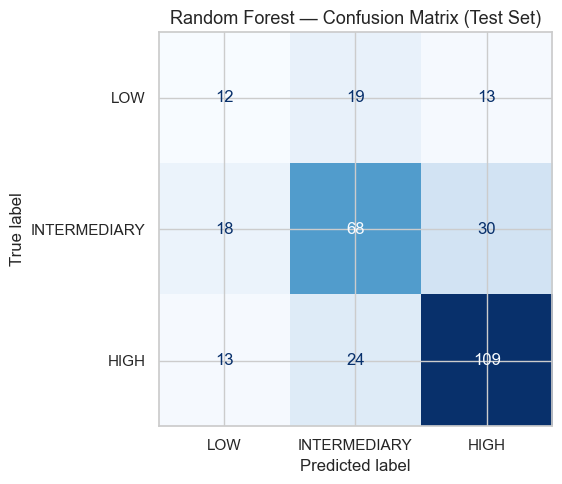

In [28]:
# Confusion Matrix — Random Forest
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Feature Importance

Feature importance scores are derived from the **mean decrease in Gini impurity** across all decision trees in the ensemble. A feature receives a higher importance score if splitting on that feature consistently produces purer (more homogeneous) child nodes throughout the forest.

The horizontal bar chart ranks all **15 features** from least to most important, with longer bars indicating greater contribution to the model's splitting decisions. The printed **top-5 list highlights** the features the model relied on most heavily.


#### 5.3.1 Logistic Regression

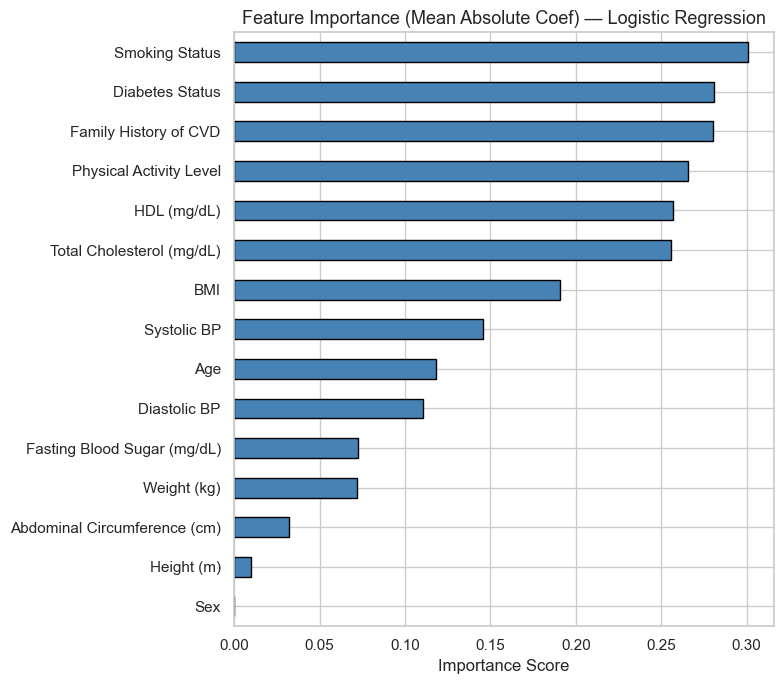

Top 5 features:
Smoking Status             0.3009
Diabetes Status            0.2810
Family History of CVD      0.2803
Physical Activity Level    0.2657
HDL (mg/dL)                0.2568


In [29]:
# Feature Importance — Logistic Regression
import numpy as np

# For multi-class (OvR), coef_ shape is (n_classes, n_features).
# We take the mean of absolute coefficients across all classes.
feature_names = X.columns.tolist()
lr_importance_vals = np.mean(np.abs(lr_best.coef_), axis=0)
lr_importance = pd.Series(lr_importance_vals, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
lr_importance.plot.barh(ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Feature Importance (Mean Absolute Coef) — Logistic Regression', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(lr_importance.sort_values(ascending=False).head().round(4).to_string())

#### 5.3.2 Random Forest

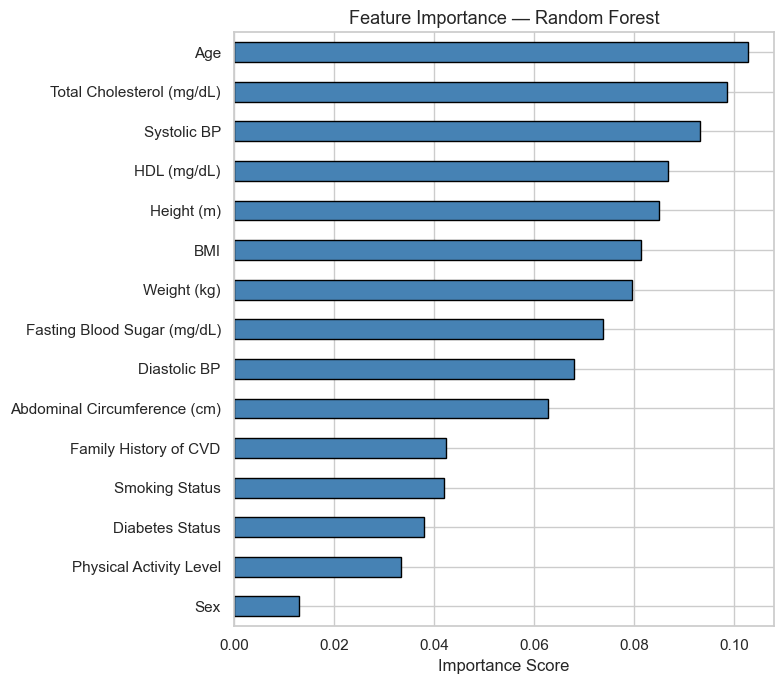

Top 5 features:
Age                          0.1028
Total Cholesterol (mg/dL)    0.0985
Systolic BP                  0.0932
HDL (mg/dL)                  0.0868
Height (m)                   0.0850


In [30]:
# Feature Importance — Random Forest
feature_names = X.columns.tolist()
rf_importance = pd.Series(rf_best.feature_importances_,
                           index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
rf_importance.plot.barh(ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Feature Importance — Random Forest', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(rf_importance.sort_values(ascending=False).head().round(4).to_string())

### 5.4 ROC Curves (One-vs-Rest)

The ROC (Receiver Operating Characteristic) curves are plotted using a **One-vs-Rest** strategy — for each class, the model's ability to distinguish that class from all others is evaluated independently. This is the standard approach for multi-class ROC analysis.

Each curve plots the **True Positive Rate** (recall for that class) against the **False Positive Rate** at all possible classification thresholds. The **dashed diagonal line** represents a random classifier with no discriminative power (AUC = 0.5) — any curve above this line indicates the model is performing better than chance.

The **Area Under the Curve (AUC)** summarises each class's curve into a single value:

| AUC Range | Interpretation |
|---|---|
| 0.90 – 1.00 | Excellent |
| 0.80 – 0.90 | Good |
| 0.70 – 0.80 | Acceptable |
| 0.60 – 0.70 | Poor |
| 0.50 – 0.60 | No better than random |

#### 5.4.1 Logistic Regression

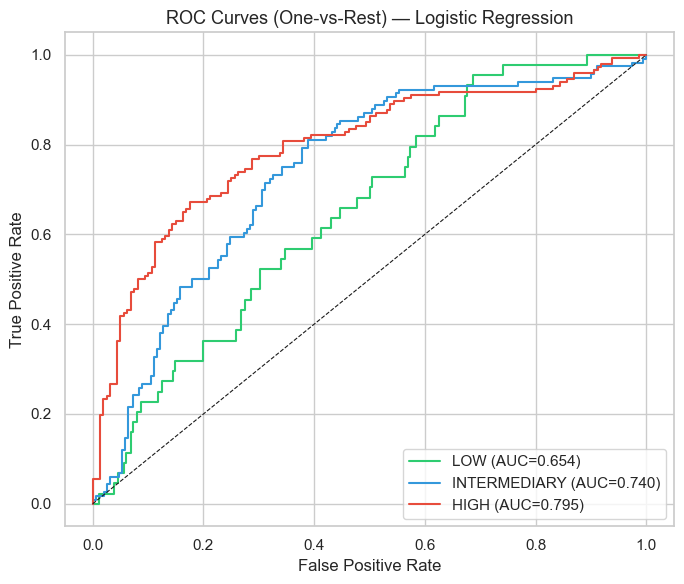

Macro-average ROC-AUC: 0.7299


In [31]:
# ROC Curves (One-vs-Rest) — Logistic Regression
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['#2ecc71', '#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(7, 6))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], lr_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], lr_prob[:, i])
    ax.plot(fpr, tpr, color=color, label=f'{cls} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('ROC Curves (One-vs-Rest) — Logistic Regression', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

macro_auc_lr = roc_auc_score(y_test, lr_prob, multi_class='ovr', average='macro')
print(f'Macro-average ROC-AUC: {macro_auc_lr:.4f}')

#### 5.4.2 Random Forest

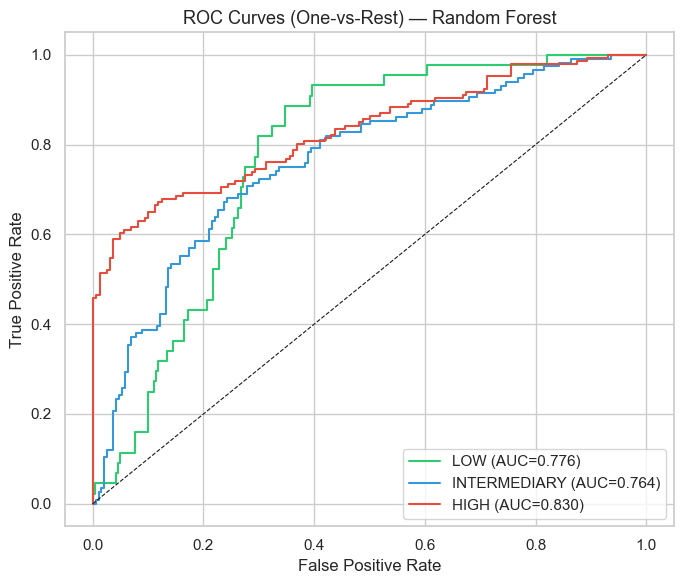

Macro-average ROC-AUC: 0.7897


In [32]:
# ROC Curves (One-vs-Rest) — Random Forest
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['#2ecc71', '#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(7, 6))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], rf_prob[:, i])
    ax.plot(fpr, tpr, color=color, label=f'{cls} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('ROC Curves (One-vs-Rest) — Random Forest', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_test, rf_prob, multi_class='ovr', average='macro')
print(f'Macro-average ROC-AUC: {macro_auc:.4f}')

### 5.5 Evaluation Summary


The evaluation summary consolidates all metrics computed across Sections 5.3–5.5 into a single reference table, providing a complete picture of the Random Forest model's performance on the **306-record test set**.

The top-level metrics are interpreted as follows:

| Metric | Interpretation |
|---|---|
| Accuracy | Proportion of all 306 test records correctly classified across all three classes |
| Macro-Precision | Average precision across LOW, INTERMEDIARY, and HIGH |
| Macro-Recall | Average recall across all three classes (**primary metric**) |
| Macro-F1 | Harmonic mean of macro-precision and macro-recall |
| LOW / INTERM. / HIGH Recall | How well the model identifies each individual risk tier |
| ROC-AUC (macro) | Overall ranking ability across all three classes using One-vs-Rest curves |


,Precision,Recall,F1-Score
LOW,0.2069,0.1364,0.1644
INTERMEDIARY,0.6154,0.6207,0.6180
HIGH,0.7063,0.7740,0.7386


,Precision,Recall,F1-Score
LOW,0.2791,0.2727,0.2759
INTERMEDIARY,0.6126,0.5862,0.5991
HIGH,0.7171,0.7466,0.7315


,Logistic Regression,Random Forest
Accuracy,0.6242,0.6176
Macro-Precision,0.5095,0.5363
Macro-Recall,0.5103,0.5352
Macro-F1,0.5070,0.5355
ROC-AUC (macro),0.7299,0.7897


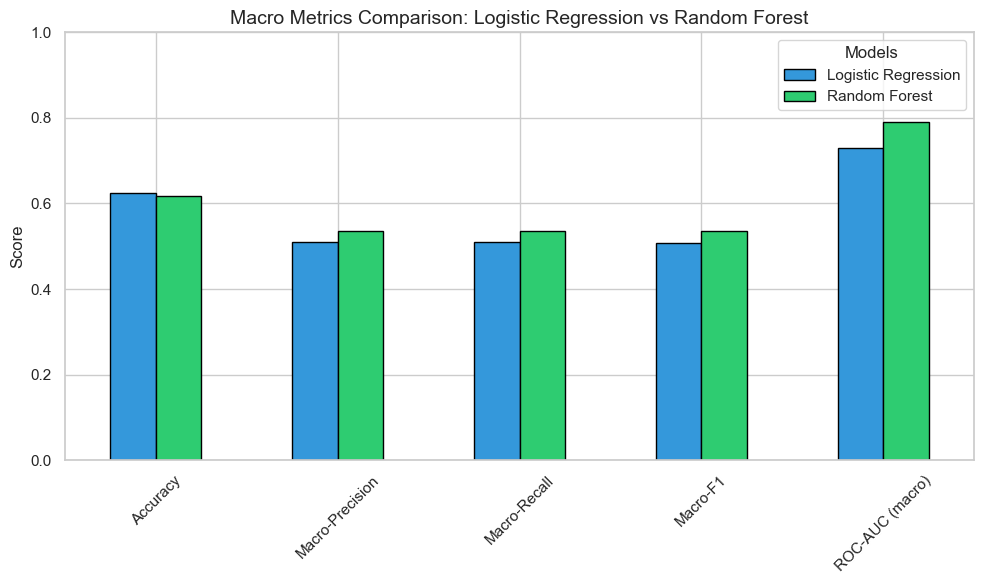

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- Logistic Regression Metrics ---
lr_per_class_recall    = recall_score(y_test, lr_pred, average=None)
lr_per_class_precision = precision_score(y_test, lr_pred, average=None, zero_division=0)
lr_per_class_f1        = f1_score(y_test, lr_pred, average=None)

# --- Random Forest Metrics ---
rf_per_class_recall    = recall_score(y_test, rf_pred, average=None)
rf_per_class_precision = precision_score(y_test, rf_pred, average=None, zero_division=0)
rf_per_class_f1        = f1_score(y_test, rf_pred, average=None)

# --- Class Breakdown (Two Separate Tables) ---
display(HTML("<h3> Per-Class Breakdown</h3>"))

lr_per_class_df = pd.DataFrame({
    'Precision': lr_per_class_precision,
    'Recall'   : lr_per_class_recall,
    'F1-Score' : lr_per_class_f1
}, index=CLASS_NAMES)

rf_per_class_df = pd.DataFrame({
    'Precision': rf_per_class_precision,
    'Recall'   : rf_per_class_recall,
    'F1-Score' : rf_per_class_f1
}, index=CLASS_NAMES)

display(HTML("<h4>Logistic Regression</h4>"))
display(lr_per_class_df.style.format("{:.4f}"))

display(HTML("<br><h4>Random Forest</h4>"))
display(rf_per_class_df.style.format("{:.4f}"))

# --- Overall Model Comparison ---
display(HTML("<hr><h3> Overall Model Comparison</h3>"))

summary_df = pd.DataFrame({
    'Logistic Regression': [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred, average='macro', zero_division=0),
        recall_score(y_test, lr_pred, average='macro'),
        f1_score(y_test, lr_pred, average='macro'),
        roc_auc_score(y_test, lr_prob, multi_class='ovr', average='macro')
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred, average='macro', zero_division=0),
        recall_score(y_test, rf_pred, average='macro'),
        f1_score(y_test, rf_pred, average='macro'),
        roc_auc_score(y_test, rf_prob, multi_class='ovr', average='macro')
    ]
}, index=[
    'Accuracy',
    'Macro-Precision',
    'Macro-Recall',
    'Macro-F1',
    'ROC-AUC (macro)'
])

# Highlight the best model per metric using a subtle, high-contrast style
styled_summary = summary_df.style.format("{:.4f}").highlight_max(
    axis=1,
    props='background-color: #d9edf7; color: #31708f; font-weight: bold;'
)
display(styled_summary)

# --- Add Gap Before Chart ---
display(HTML("<br><hr><br>"))

# --- Visualization ---
fig, ax = plt.subplots(figsize=(10, 6))
summary_df.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71'], edgecolor='black')
ax.set_title('Macro Metrics Comparison: Logistic Regression vs Random Forest', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=45)
ax.legend(title="Models")
plt.tight_layout()
plt.show()


## 5.6 Final Model Evaluation Analysis
Based on the evaluation summary and visualizations, here are the key takeaways regarding model performance:
### 5.6.1 Per-Class Breakdown
* **LOW Risk (Minority Class):** Random Forest performs twice as well as Logistic Regression here (Recall: 27.2% vs 13.6%), though both models struggle with this minority class.
* **INTERMEDIARY Risk:** Both models perform similarly, with Logistic Regression having a very slight edge in F1-score (61.8% vs 59.9%).
* **HIGH Risk (Critical Class):** Both perform very well, but Logistic Regression is slightly better at correctly identifying these critical patients, missing fewer cases (Recall: 77.4% vs 74.6%).
### 5.6.2 Overall Model Comparison
* **Overall Winner (Random Forest):** Random Forest outperforms Logistic Regression across all balanced macro metrics (Macro-Precision, Macro-Recall, and Macro-F1).
* **The Accuracy Trap:** Logistic Regression has a slightly higher Accuracy (62.4% vs 61.8%). However, it only achieves this by over-predicting the majority classes and ignoring the LOW risk patients. Random Forest is the more balanced model.
### 5.6.3 Visualization (ROC-AUC)
* **Class Separation:** Random Forest significantly dominates the ROC-AUC score (0.7897 vs 0.7299), as clearly highlighted in the bar chart.
* **Conclusion:** This indicates that Random Forest is substantially better at probabilistically separating the three risk tiers and correctly ranking a patient's severity.

---
## 6. Deployment (Proposed Plan)
*(Author: Hajar)*

> **Note:** This section describes the *intended deployment plan* for the final project. No application has been built at the proposal stage.

### 6.1 Deployment Approach

The trained machine learning model will be deployed as an interactive **Streamlit** web application. The tool will allow healthcare staff to input patient clinical attributes and receive a model-generated risk probability score.

Streamlit is selected for its Python compatibility, minimal setup overhead, and suitability for rapid academic prototyping.

### 6.2 Intended System Functionality

The planned system will:

### 6.3 Model Integration Plan

```

---
## 7. Conclusion and Future Recommendation
*(Author: Hajar)*

>

---
## References

[1] A. B. Nassif, O. Mahdi, Q. Nasir, M. AbuTalib, and M. Azzeh, "Machine learning classifications of coronary artery disease," in *2018 International Joint Symposium on Artificial Intelligence and Natural Language Processing (iSAI-NLP)*, 2018, pp. 1–6, doi: 10.1109/iSAI-NLP.2018.8692895.

[2] E. Kavlakoglu, "What is logistic regression?," IBM. [Online]. Available: https://www.ibm.com/think/topics/logistic-regression. [Accessed: April 23, 2026].

[3] E. Kavlakoglu, "What is random forest?," IBM. [Online]. Available: https://www.ibm.com/think/topics/random-forest. [Accessed: April 23, 2026].

[4] R. Kundu, "F1 Score in Machine Learning: Intro & Calculation," v7labs. [Online]. Available: https://www.v7labs.com/blog/f1-score-guide. [Accessed: April 24, 2026].

[5] R. Detrano et al., "International application of a new probability algorithm for the diagnosis of coronary artery disease," *American Journal of Cardiology*, 1989.

## Members' Contribution
| Member | Student ID | Role |
|--------|-----------|------|
| Xiao Shulei | 25084582 | Business Understanding + Data Understanding + EDA |
| Kausaliya A/P Nanthakumar | 17206793 | Business Understanding + Data Understanding + EDA |
| Ung Keng Jie | 25084156 | Modelling + Evaluation |
| Shindujaah Jaya Kumar | 25087626 | Data Preparation |
| Rakib Hasann | 23099815 | Modelling + Evaluation |
| Hajar Amani Binti Hamim | 25087789 | Deployment |

In [35]:
import joblib

# Export the trained Random Forest model
# Note: Ensure your random forest variable is named 'rf_model' or change the name accordingly
joblib.dump(rf_best, 'random_forest_model.pkl')



['random_forest_model.pkl']